## Stuff for Cedefop Presentation
07.10.2021

In [38]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.5)

Define paths to lfs data

In [39]:
# project directory
abspath = os.path.abspath('')
project_dir = str(Path(abspath).parents[0])

# sub-directories
data_raw = os.path.join(project_dir, "data", "raw")
data_interim = os.path.join(project_dir, "data", "interim")
data_external = os.path.join(project_dir, "data", "external")
data_processed = os.path.join(project_dir, "data", "processed")

fpath_lfs = r"C:\eurostat_data"
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

Read geodata with NUTS regions

In [40]:
gdf = gpd.read_file(os.path.join(data_external, "geodata", "NUTS_RG_03M_2021_4326_LEVL_2", "NUTS_RG_03M_2021_4326_LEVL_2.shp"))

Read preprocessed LFS data (all countries, 2019)

In [41]:
df_de = pd.read_csv(os.path.join(data_processed, "lfs", "eu_lfs_merged_allyears_de.csv"), index_col=0)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_11536\504243826.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_de = pd.read_csv(os.path.join(data_processed, "lfs", "eu_lfs_merged_allyears_de.csv"), index_col=0)


#### Estimate absolute and relative employment shares in GBN for NUTS2 regions

In [42]:
df_de_merged_by_nuts = df_de.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
df_de_merged_by_nuts

df_de_merged_by_nuts["is_brown_pc"] = df_de_merged_by_nuts.is_brown_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_neutral_pc"] = df_de_merged_by_nuts.is_neutral_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_green_pc"] = df_de_merged_by_nuts.is_green_abs / df_de_merged_by_nuts.COEFF

In [43]:
gdf_de_merged_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_de_merged_by_nuts,
    on="NUTS_ID",
    how="left"
)

#### Median coreness of brown occupations at regional level

In [44]:
# read coreness data for skills
# todo: refactor to point to MCC directory
coreness = pd.read_csv(os.path.join(data_interim, "skills_coreness_measure.csv"), index_col=0)

In [45]:
# Read occupations with their ISCO level
occ = pd.read_csv(os.path.join(data_raw, "esco", "v1.0.3", "occupations_en.csv"))
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix
occ_skills_mat = pd.read_pickle(os.path.join(data_interim, "adjacency_matrix_essential_optional.pkl"))
occ_skills_mat[occ_skills_mat == 2] = 0.5

In [46]:
# multiply with coreness measure (coreness is down-weighted for optional skills)
coreness_vectors = occ_skills_mat.apply(lambda x: np.asarray(x) * np.asarray(coreness.coreness), axis=1).values

df_coreness_vectors = pd.DataFrame(
    data=np.vstack(coreness_vectors),
    index=occ_skills_mat.index,
    columns=occ_skills_mat.columns
)

In [47]:
# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

In [48]:
# Aggregate to ISCO 3-digit level (mean coreness)
df_coreness_vectors.index = index
df_coreness_vectors_isco3 = df_coreness_vectors.groupby(df_coreness_vectors.index.get_level_values(1)).mean()

In [49]:
df_coreness_vectors_isco3_mean = df_coreness_vectors_isco3[df_coreness_vectors_isco3 != 0].mean(axis=1).to_frame("coreness_mean")
df_coreness_vectors_isco3_median = df_coreness_vectors_isco3[df_coreness_vectors_isco3 != 0].median(axis=1).to_frame("coreness_median")
df_coreness_isco3 = pd.concat([df_coreness_vectors_isco3_mean, df_coreness_vectors_isco3_median], axis=1).reset_index()

In [50]:
df_de.ISCO3D = df_de.ISCO3D.astype(str)
df_de.ISCO3D = df_de.ISCO3D.str.pad(width=3, side="right", fillchar="0")

In [51]:
df_de_coreness = pd.merge(
    df_de,
    df_coreness_isco3,
    left_on="ISCO3D",
    right_on="isco_3_digit",
    how="left"
)

In [52]:
df_de_coreness.is_neutral

0          1.000000
1          1.000000
2          0.416667
3          1.000000
4          0.812500
             ...   
1939603    1.000000
1939604    1.000000
1939605    0.179487
1939606    0.905172
1939607    1.000000
Name: is_neutral, Length: 1939608, dtype: float64

Weighted mean with groupby: https://stackoverflow.com/questions/31521027/groupby-weighted-average-and-sum-in-pandas-dataframe

In [53]:
def weighted_average(df,data_col,weight_col,by_col):
    df['_data_times_weight'] = df[data_col]*df[weight_col]
    df['_weight_where_notnull'] = df[weight_col]*pd.notnull(df[data_col])
    g = df.groupby(by_col)
    result = g['_data_times_weight'].sum() / g['_weight_where_notnull'].sum()
    del df['_data_times_weight'], df['_weight_where_notnull']
    return result

o_i ... occupations at ESCO level
o_x occupations at isco 3-digit level

s_j ... skills at ESCO level
c_j ... vector of coreness values per skill s_j

M_ij shows which skills s_j are required by each occupation o_i (occupation-skills matrix)
C_ij shows the coreness of each skills s_j required by each occupation o_i

-> i multiplied each row in M_ij with the corresponding coreness vector c_j, yielding C_ij
-> i aggregated C_ij to the ISCO 3-digit level by taking the mean over the corresponding columns, yielding C_xj
-> i then took the mean of C_xj over all skills j, yielding mean coreness scores per ISCO 3-digit occupation, c_x
-> i matched those coreness scores to our LFS data set (each sample with the same occupation gets the same mean coreness score)
-> i calculated regional weighted means of those coreness scores by using the absolute number of brown jobs at the regional level as the weights: 
-> for one region: sum(n_brown_jobs_i * coreness_i) / sum(n_brown_jobs_i) where i corresponds to one surveyed individual

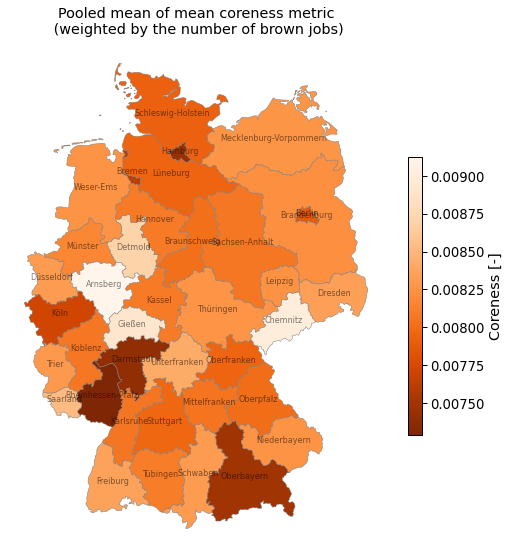

In [54]:
# calc weighted mean of mean
df_de_coreness_by_nuts = df_de_coreness.groupby("NUTS_ID").aggregate({"COEFF": np.sum, "is_brown_abs": np.sum, "coreness_mean": np.mean})
df_de_coreness_by_nuts["coreness_weighted_mean_of_mean"] = weighted_average(df=df_de_coreness, data_col="coreness_mean", weight_col="is_brown_abs", by_col="NUTS_ID")
df_de_coreness_by_nuts["coreness_weighted_mean_of_median"] = weighted_average(df=df_de_coreness, data_col="coreness_median", weight_col="is_brown_abs", by_col="NUTS_ID")

# merge
gdf_de_coreness_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_de_coreness_by_nuts,
    on="NUTS_ID",
    how="left"
)

gdf_de_coreness_by_nuts["above_median_brown"] = gdf_de_coreness_by_nuts.is_brown_abs > gdf_de_coreness_by_nuts.is_brown_abs.median()

# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15
gdf_de_coreness_by_nuts.plot(ax=ax, column="coreness_weighted_mean_of_mean", figsize=(10, 5), legend=True, cmap="Oranges_r", legend_kwds={"label": "Coreness [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title("Pooled mean of mean coreness metric\n (weighted by the number of brown jobs)")

ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "pooled_coreness_mean_weighted_by_brown_jobs.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

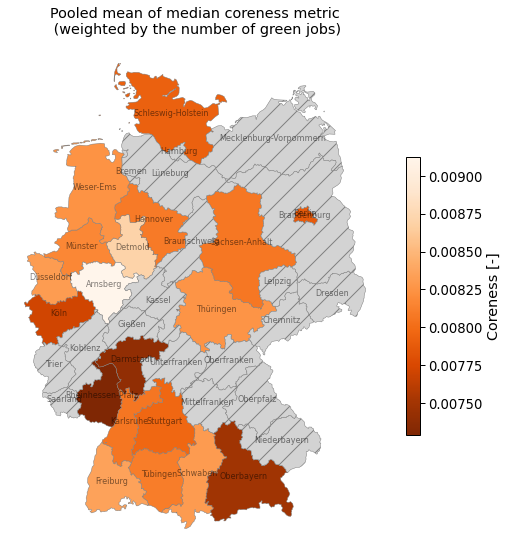

In [55]:
gdfc = gdf_de_coreness_by_nuts.copy()
gdfc.loc[~gdfc.above_median_brown, "coreness_weighted_mean_of_mean"] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15
gdfc.plot(ax=ax, column="coreness_weighted_mean_of_mean", figsize=(10, 5), legend=True, cmap="Oranges_r", legend_kwds={"label": "Coreness [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title("Pooled mean of median coreness metric\n (weighted by the number of green jobs)")

ax.axis('off')
gdfc.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "pooled_coreness_mean_weighted_by_brown_jobs_top_50pc_brown.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

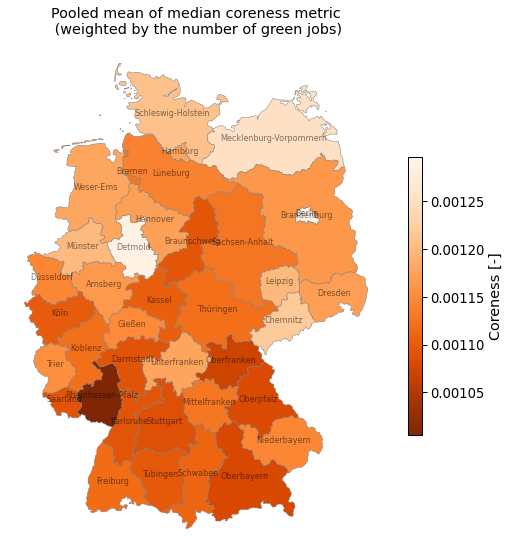

In [56]:
# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15
gdf_de_coreness_by_nuts.plot(ax=ax, column="coreness_weighted_mean_of_median", figsize=(10, 5), legend=True, cmap="Oranges_r", legend_kwds={"label": "Coreness [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title("Pooled mean of median coreness metric\n (weighted by the number of green jobs)")

ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "pooled_coreness_median_weighted_by_brown_jobs.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

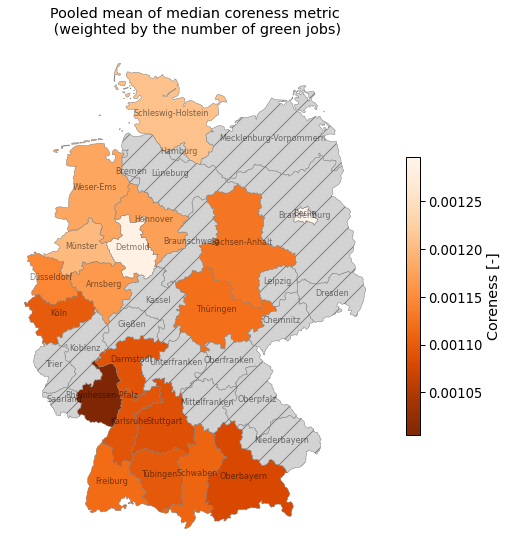

In [57]:
gdfc = gdf_de_coreness_by_nuts.copy()
gdfc.loc[~gdfc.above_median_brown, "coreness_weighted_mean_of_median"] = np.nan

# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15
gdfc.plot(ax=ax, column="coreness_weighted_mean_of_median", figsize=(10, 5), legend=True, cmap="Oranges_r", legend_kwds={"label": "Coreness [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title("Pooled mean of median coreness metric\n (weighted by the number of green jobs)")

ax.axis('off')
gdfc.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "pooled_coreness_median_weighted_by_brown_jobs_top_50pc_brown.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

#### New ideas

$risk = \frac{b}{\sigma_b} * \frac{1}{\frac{c}{\sigma_c}}$ with c ... coreness, b ... number of brown jobs

In [58]:
# calc risk metric
sigma_brown = gdf_de_coreness_by_nuts.is_brown_abs.std()
sigma_coreness = gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()
gdf_de_coreness_by_nuts["risk_metric"] = (gdf_de_coreness_by_nuts.is_brown_abs / sigma_brown) * (1 / (gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean / sigma_coreness))

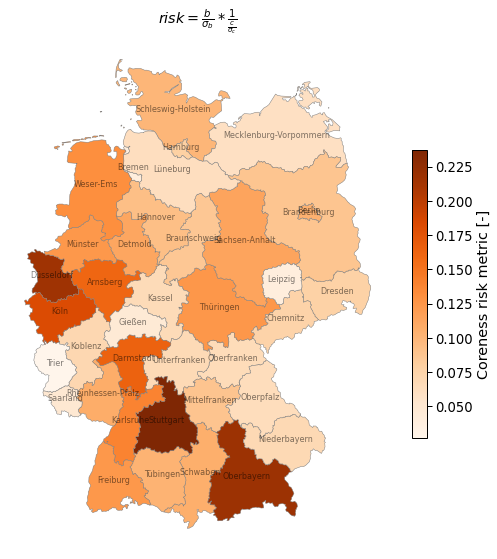

In [59]:
# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15
gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric", figsize=(10, 5), legend=True, cmap="Oranges", legend_kwds={"label": "Coreness risk metric [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title(r"$risk = \frac{b}{\sigma_b} * \frac{1}{\frac{c}{\sigma_c}}$")

ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

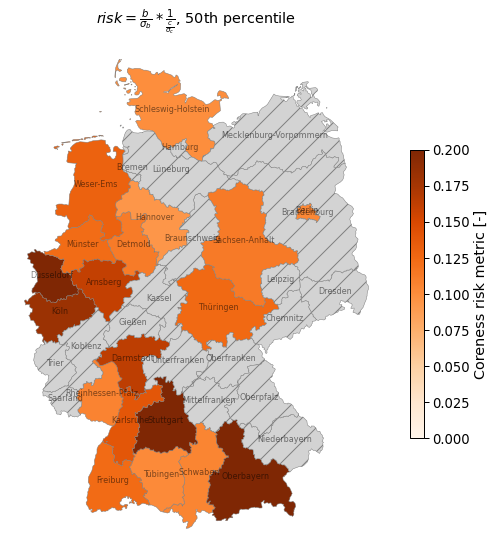

In [60]:
# plot
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = 0.0, 0.15

gdfc = gdf_de_coreness_by_nuts.copy()
gdfc.loc[~gdfc.above_median_brown, "risk_metric"] = np.nan

gdfc.plot(ax=ax, column="risk_metric", figsize=(10, 5), legend=True, cmap="Oranges", vmin=0, vmax=0.2, legend_kwds={"label": "Coreness risk metric [-]", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})
ax.set_title(r"$risk = \frac{b}{\sigma_b} * \frac{1}{\frac{c}{\sigma_c}}$, 50th percentile")

ax.axis('off')
gdfc.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_top_50pc_brown.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

#### Why are Stuttgart and Oberbayern ranking so high?
- number of brown jobs b is proportionately higher there because overall population is high. the pattern overall seems to mirror population size.

In [61]:
df_de_named = pd.merge(
    df_de,
    gdf[["NUTS_ID", "NUTS_NAME"]],
    on="NUTS_ID",
    how="left"
)

In [62]:
df_de_named.loc[df_de_named.NUTS_NAME == "Stuttgart"].groupby("NACE1D_label").COEFF.sum().sort_values(ascending=False)

NACE1D_label
Manufacturing                                                                                                                5.285419e+06
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles                                                         2.163503e+06
Human Health and Social Work Activities                                                                                      1.779254e+06
Education                                                                                                                    1.083065e+06
Construction                                                                                                                 1.062957e+06
Professional, Scientific and Technical Activities                                                                            9.886247e+05
Public Administration and Defence; Compulsory Social Security                                                                9.668616e+05
Administrative and Su

In [63]:
df_de_named.loc[df_de_named.NUTS_NAME == "Oberbayern"].groupby("NACE1D_label").COEFF.sum().sort_values(ascending=False)

NACE1D_label
Manufacturing                                                                                                                3.904277e+06
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles                                                         2.505707e+06
Human Health and Social Work Activities                                                                                      2.228811e+06
Professional, Scientific and Technical Activities                                                                            1.693400e+06
Public Administration and Defence; Compulsory Social Security                                                                1.306203e+06
Construction                                                                                                                 1.215853e+06
Education                                                                                                                    1.206869e+06
Information and Commu

In [64]:
df_de_named.loc[df_de_named.NUTS_NAME == "Trier"].groupby("ISCO3D_label").aggregate({"COEFF": np.sum, "is_brown": np.mean}).sort_values("COEFF", ascending=False).head(30)

,COEFF,is_brown
ISCO3D_label,,
Shop salespersons,137630.6675,0.000000
Material-recording and transport clerks,78545.7800,0.074074
Nursing and midwifery associate professionals,70161.8475,0.000000
"Domestic, hotel and office cleaners and helpers",69297.2250,0.000000
Secretaries (general),67013.9925,0.000000
Administrative and specialised secretaries,65918.0175,0.000000
"Legal, social and religious associate professionals",63359.5525,0.000000
"Mining, manufacturing and construction supervisors",48349.8925,0.508197
Physical and engineering science technicians,47604.0875,0.085938


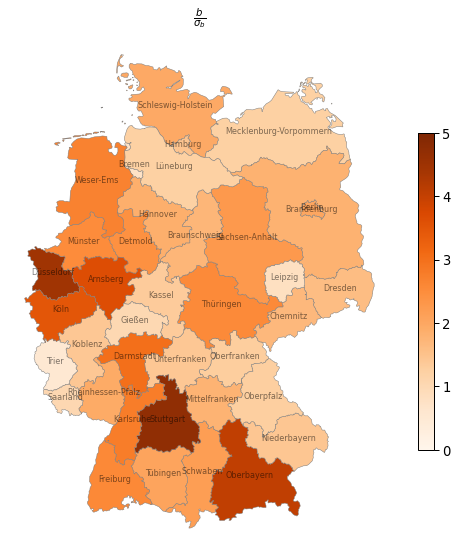

In [65]:
gdf_de_coreness_by_nuts["is_brown_abs_norm"] = gdf_de_coreness_by_nuts.is_brown_abs / gdf_de_coreness_by_nuts.is_brown_abs.std()

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="is_brown_abs_norm", figsize=(10, 5), legend=True, cmap="Oranges", vmin=0, vmax=5, legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b}{\sigma_b}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_first_component.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

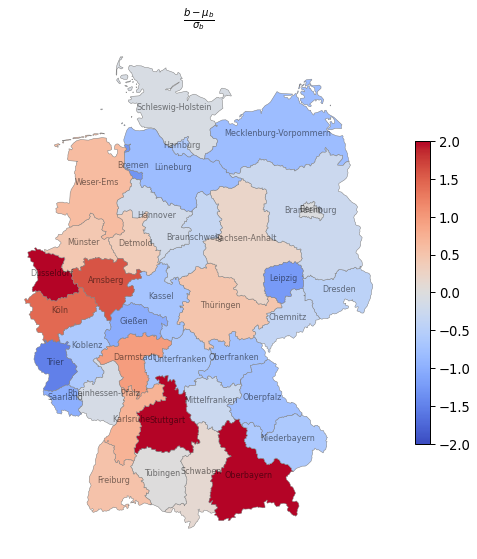

In [66]:
gdf_de_coreness_by_nuts["is_brown_abs_norm"] = (gdf_de_coreness_by_nuts.is_brown_abs - gdf_de_coreness_by_nuts.is_brown_abs.mean()) / gdf_de_coreness_by_nuts.is_brown_abs.std()

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="is_brown_abs_norm", figsize=(10, 5), legend=True, cmap="coolwarm", vmin=-2, vmax=2, legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_first_component_zscored.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

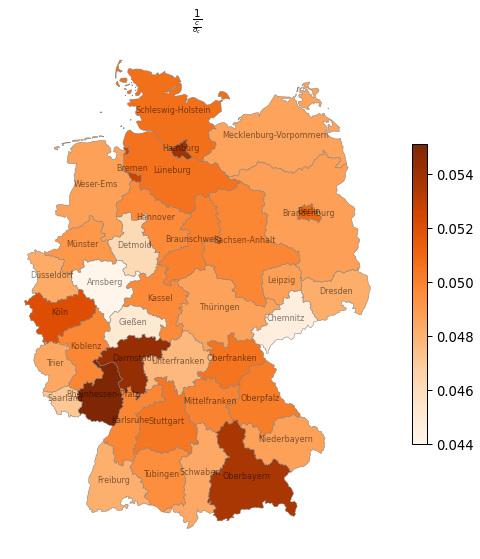

In [67]:
gdf_de_coreness_by_nuts["coreness_weighted_mean_norm_inv"] = (1 / (gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean / sigma_coreness))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="coreness_weighted_mean_norm_inv", figsize=(10, 5), legend=True, cmap="Oranges", legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{1}{\frac{c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_second_component.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

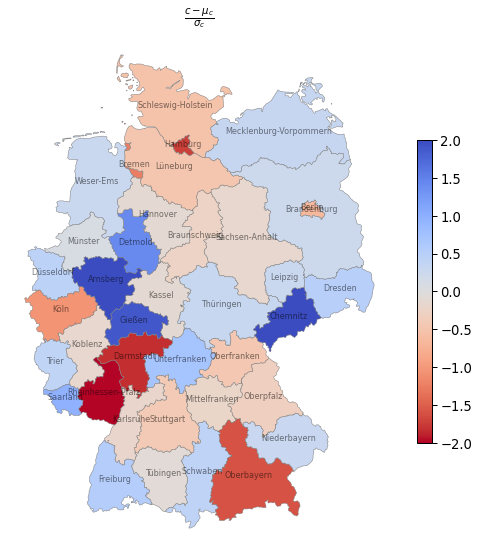

In [68]:
gdf_de_coreness_by_nuts["coreness_weighted_mean_norm_inv"] = ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std())

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="coreness_weighted_mean_norm_inv", figsize=(10, 5), vmin=-2, vmax=2, legend=True, cmap="coolwarm_r", legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{c - \mu_c}{\sigma_c}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_second_component_zscored.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

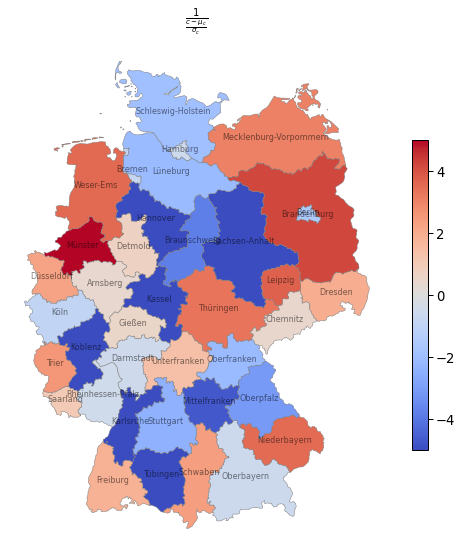

In [69]:
gdf_de_coreness_by_nuts["coreness_weighted_mean_norm_inv"] = 1 / ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std())

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="coreness_weighted_mean_norm_inv", figsize=(10, 5), vmin=-5, vmax=5, legend=True, cmap="coolwarm", legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_second_component_zscored_inv.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

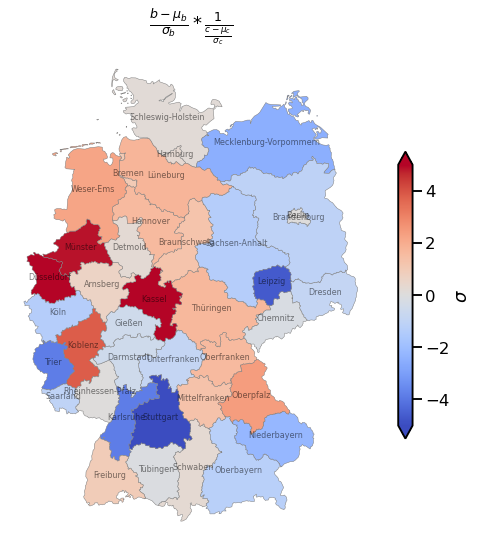

In [70]:
sns.set_context("talk")

gdf_de_coreness_by_nuts["risk_metric_zscored"] = ((gdf_de_coreness_by_nuts.is_brown_abs - gdf_de_coreness_by_nuts.is_brown_abs.mean()) / gdf_de_coreness_by_nuts.is_brown_abs.std()) * (1 / ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric_zscored", vmin=-5, vmax=5, figsize=(10, 5), legend=True, cmap="coolwarm", legend_kwds={"label": r"$\sigma$", "fraction": 0.03, "extend": "both"}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b} * \frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_zscored.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

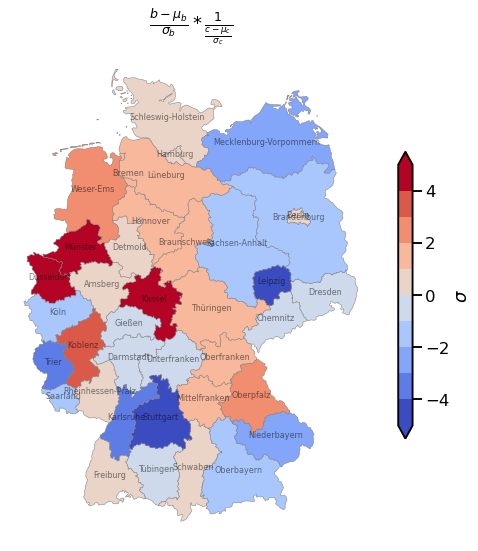

In [71]:
sns.set_context("talk")

gdf_de_coreness_by_nuts["risk_metric_zscored"] = ((gdf_de_coreness_by_nuts.is_brown_abs - gdf_de_coreness_by_nuts.is_brown_abs.mean()) / gdf_de_coreness_by_nuts.is_brown_abs.std()) * (1 / ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric_zscored", vmin=-5, vmax=5, figsize=(10, 5), legend=True, cmap=plt.get_cmap("coolwarm", 10), legend_kwds={"label": r"$\sigma$", "fraction": 0.03, "extend": "both"}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b} * \frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_zscored_cmap.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

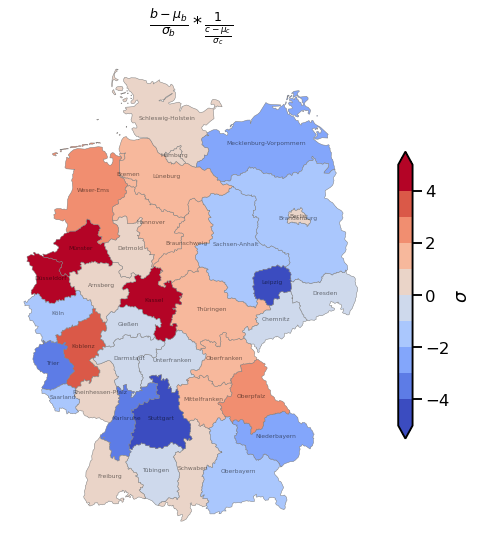

In [72]:
sns.set_context("talk")

gdf_de_coreness_by_nuts["risk_metric_zscored"] = ((gdf_de_coreness_by_nuts.is_brown_abs - gdf_de_coreness_by_nuts.is_brown_abs.mean()) / gdf_de_coreness_by_nuts.is_brown_abs.std()) * (1 / ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric_zscored", vmin=-5, vmax=5, figsize=(10, 5), legend=True, cmap=plt.get_cmap("coolwarm", 10), legend_kwds={"label": r"$\sigma$", "fraction": 0.03, "extend": "both"}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b} * \frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=6, color="k"), axis=1)

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_zscored_v2.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

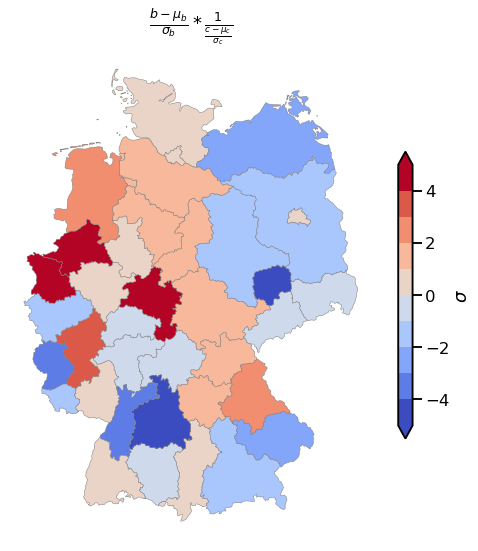

In [73]:
sns.set_context("talk")

gdf_de_coreness_by_nuts["risk_metric_zscored"] = ((gdf_de_coreness_by_nuts.is_brown_abs - gdf_de_coreness_by_nuts.is_brown_abs.mean()) / gdf_de_coreness_by_nuts.is_brown_abs.std()) * (1 / ((gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean - gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.mean()) / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric_zscored", vmin=-5, vmax=5, figsize=(10, 5), legend=True, cmap=plt.get_cmap("coolwarm", 10), legend_kwds={"label": r"$\sigma$", "fraction": 0.03, "extend": "both"}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b} * \frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')

plt.tight_layout()

# plt.savefig(
#     os.path.join(fpath_lfs, "felix", "figures", "coreness_risk_metric_zscored_v3.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

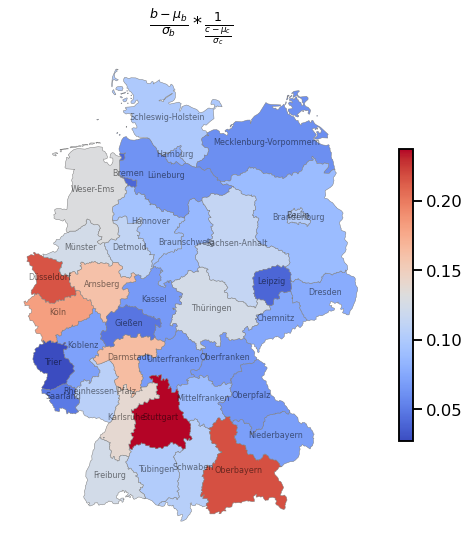

In [74]:
gdf_de_coreness_by_nuts["risk_metric_normal"] = (gdf_de_coreness_by_nuts.is_brown_abs / gdf_de_coreness_by_nuts.is_brown_abs.std()) * (1 / (gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean / gdf_de_coreness_by_nuts.coreness_weighted_mean_of_mean.std()))

# plot
fig, ax = plt.subplots(figsize=(8, 8))

gdf_de_coreness_by_nuts.plot(ax=ax, column="risk_metric_normal", figsize=(10, 5), legend=True, cmap="coolwarm", legend_kwds={"label": "", "fraction": 0.03}, edgecolor="grey", linewidth=0.5, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"})

ax.set_title(r"$\frac{b - \mu_b}{\sigma_b} * \frac{1}{\frac{c - \mu_c}{\sigma_c}}$")
ax.axis('off')
gdf_de_coreness_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8, color="k"), axis=1)

plt.tight_layout()